In [81]:
import os
import pickle
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [83]:
path = "results/{0}_fig7_rho_sub_critical_test_2.p"
#N_range = [int(n) for n in np.geomspace(1e5, 3e6, 10)]
N_range = [ 100000,  145923,  212936, 310723]
num_ensambles = 1700
M = np.empty((len(N_range), num_ensambles))

In [96]:
for n in range(num_ensambles):
    with open(path.format(n), "rb") as f:
        mags = pickle.load(f)
        print(mags)
        for N in range(len(N_range)):
            m = mags[N]
            M[N,n] = m

[0.02976, 0.4345765863921554, 0.0256162496659197, 0.03468362496500098]
[0.0484, 0.03475222602096405, 0.027329481987075376, 0.04375923249968622]
[0.04979, 0.4419403013111921, 0.4392590612857466, 0.03708447717098509]
[0.03228, 0.028224443025134313, 0.4459406673382537, 0.4400929445197169]
[0.03767, 0.042449374459931626, 0.03290091349547364, 0.052651396903351216]
[0.44064, 0.4328624563249051, 0.02499263310101903, 0.04585756445451415]
[0.02409, 0.041157906601044444, 0.03704008278338576, 0.026824535036028874]
[0.44996, 0.02277679678401022, 0.04993044276776108, 0.045777106940908786]
[0.0304, 0.4380518089942518, 0.4350308039171344, 0.0304837427548009]
[0.43635, 0.025834053424503137, 0.04002110702219664, 0.03351216356690686]
[0.44783, 0.43916481947627456, 0.02660992441218999, 0.44672908024188746]
[0.43957, 0.03946256152083255, 0.03479917490731413, 0.020078977095355027]
[0.03201, 0.02899462749370703, 0.04555827388417179, 0.04060529796635588]
[0.02052, 0.02414810083781042, 0.02941277248960068, 0.

[0.03463470460448319, 0.038950670624037266, 0.0483324375730152, 0.42867]
[0.029798244738883185, 0.04145, 0.029107337415937184, 0.029001596732523317]
[0.04057557200285532, 0.026068542998704796, 0.44146, 0.04085954370934884]
[0.05046497125196165, 0.028111733102904157, 0.43108, 0.030345355831399672]
[0.45326764849532253, 0.44571531557045985, 0.45283, 0.43715521199536744]
[0.4298756433858061, 0.037866524203229245, 0.44779, 0.02733633491636]
[0.4322081081863911, 0.03255141410195788, 0.44446218582109176, 0.04827]
[0.03096, 0.024185528589772885, 0.040295224193581544, 0.026745125295863547]
[0.4417374960978106, 0.05494678700410491, 0.05347616185144832, 0.03192]
[0.039903708447717096, 0.060863358004282976, 0.430459900084291, 0.44605]
[0.4587, 0.052873459640902024, 0.0430082278243228, 0.43200866210261574]
[0.056735401547391436, 0.43188305983142544, 0.032249126498102715, 0.03515]
[0.02967594931820303, 0.4233739712039912, 0.01969, 0.040763421873238906]
[0.028082890548816793, 0.43202, 0.450847364706

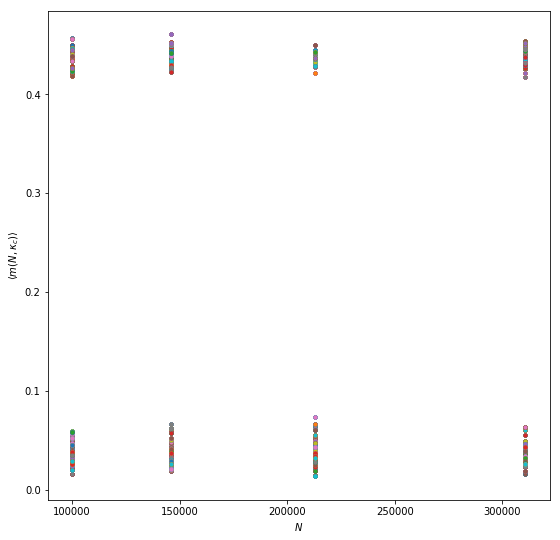

In [32]:
plt.figure(figsize=(9,9))
for n in range(num_ensambles):
    plt.scatter(N_range, M[:, n], s=10)
plt.xlabel(r'$N$')
plt.ylabel(r'$\langle m(N, \kappa_c)\rangle$')
plt.show()

In [97]:
pairs = []

for N in range(len(N_range)):
    ms = M[N]
    md = ms[ms <=0.25]
    if md.size >= ms.size//4:
        pairs.append([N_range[N], 0.0559263564072972-np.mean(md), np.std(md)])
        
pairs = np.array(pairs)

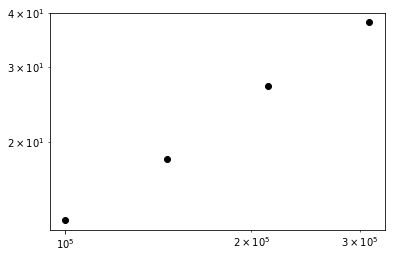

In [89]:
pairs = []

for N in range(len(N_range)):
    ms = M[N]
    md = ms[ms <=0.25]
    if md.size >= 0:#ms.size//4:
        pairs.append([N_range[N], N_range[N]*(np.mean(md**2)-np.mean(md)**2)])
        
pairs = np.array(pairs)

plt.loglog(*pairs[:,:2].T, 'ko')
plt.show()

In [98]:
z = np.polyfit(np.log(pairs[:, 0]), np.log(pairs[:, 1]), 1)
print(z)
p = np.poly1d(z)

[ 0.01505286 -4.1157714 ]


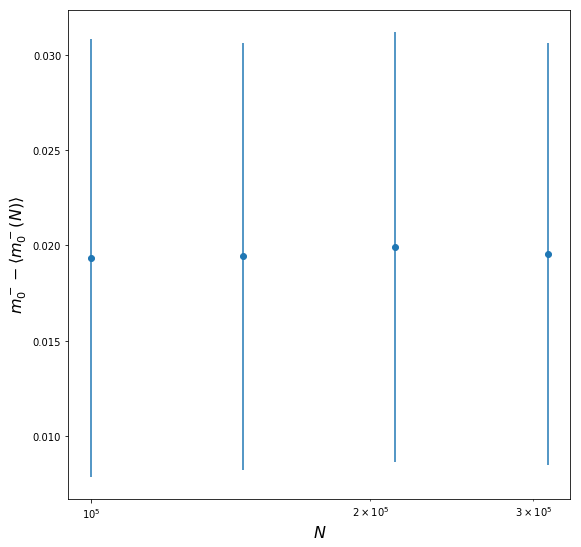

In [100]:
plt.figure(figsize=(9,9))
plt.errorbar(*pairs[:, :2].T, yerr=pairs[:, 2], fmt='o')
#plt.plot(pairs[:, 0], p(np.log(pairs[:, 0])))
plt.ylabel(r'$m_0^--\langle m_0^-(N)\rangle$', fontsize=16)
plt.xlabel(r'$N$', fontsize=16)
plt.xscale('log')
#plt.yscale('log')
plt.show()

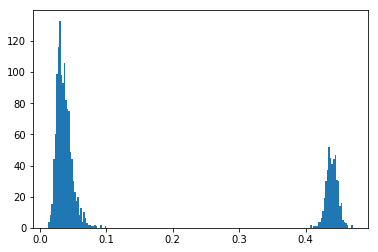

In [91]:
plt.hist(M[0,:], bins=200)
plt.show()